Building likelihood maps for a set of representative images.

> TODO: use images from dataset and superimpose the bounding boxes on them

In [1]:
from retinotopy import *


HOST='Ahsoka'
On date 2024-04-25, Running learning on host Ahsoka with device cpu
Welcome on macOS-14.4.1-x86_64-i386-64bit


In [2]:
args = Params()
data_set_type = 'full'
args.root  = f'{DATAROOT}/Imagenet_{data_set_type}' # Directory containing images
args.folders = ['val'] # type of images to use
    

In [3]:
# %ls {args.root}/{args.folders[0]}

In [25]:

image_dataset = torchvision.datasets.ImageFolder(os.path.join(args.root, args.folders[0]), transform=T.Compose([T.ToImage(), T.ToDtype(torch.float32, scale=True)]))
dataloader = torch.utils.data.DataLoader(image_dataset, batch_size=1, shuffle=True, num_workers=1)
len(image_dataset)

50001

In [6]:
for full_image, label in dataloader:
    break
full_image.shape, label

(torch.Size([1, 3, 375, 500]), tensor([734]))

In [9]:
dataloader.dataset.classes[label[0]]


'n03977966'

In [12]:

dataloader.dataset.samples[0]

('/Volumes/data/2024_archives/2024_science/Deep_learning/data/Imagenet_full/val/n01440764/ILSVRC2012_val_00000293.JPEG',
 0)

In [26]:
for i in range(10): print(dataloader.dataset.imgs[i][0])

/Volumes/data/2024_archives/2024_science/Deep_learning/data/Imagenet_full/val/n01440764/ILSVRC2012_val_00000293.JPEG
/Volumes/data/2024_archives/2024_science/Deep_learning/data/Imagenet_full/val/n01440764/ILSVRC2012_val_00002138.JPEG
/Volumes/data/2024_archives/2024_science/Deep_learning/data/Imagenet_full/val/n01440764/ILSVRC2012_val_00003014.JPEG
/Volumes/data/2024_archives/2024_science/Deep_learning/data/Imagenet_full/val/n01440764/ILSVRC2012_val_00006697.JPEG
/Volumes/data/2024_archives/2024_science/Deep_learning/data/Imagenet_full/val/n01440764/ILSVRC2012_val_00007197.JPEG
/Volumes/data/2024_archives/2024_science/Deep_learning/data/Imagenet_full/val/n01440764/ILSVRC2012_val_00009111.JPEG
/Volumes/data/2024_archives/2024_science/Deep_learning/data/Imagenet_full/val/n01440764/ILSVRC2012_val_00009191.JPEG
/Volumes/data/2024_archives/2024_science/Deep_learning/data/Imagenet_full/val/n01440764/ILSVRC2012_val_00009346.JPEG
/Volumes/data/2024_archives/2024_science/Deep_learning/data/Imag

In [31]:
idx = 324
image_dataset[idx], image_dataset.samples[idx]

((Image([[[0.125, 0.153, 0.153,  ..., 0.157, 0.161, 0.173],
          [0.153, 0.153, 0.157,  ..., 0.165, 0.173, 0.176],
          [0.161, 0.157, 0.165,  ..., 0.184, 0.184, 0.188],
          ...,
          [0.176, 0.176, 0.176,  ..., 0.514, 0.518, 0.525],
          [0.184, 0.176, 0.165,  ..., 0.518, 0.525, 0.529],
          [0.169, 0.153, 0.133,  ..., 0.522, 0.525, 0.533]],
  
         [[0.553, 0.569, 0.561,  ..., 0.604, 0.608, 0.612],
          [0.561, 0.557, 0.561,  ..., 0.596, 0.596, 0.600],
          [0.565, 0.549, 0.557,  ..., 0.608, 0.608, 0.612],
          ...,
          [0.231, 0.231, 0.239,  ..., 0.694, 0.698, 0.706],
          [0.231, 0.239, 0.235,  ..., 0.698, 0.706, 0.710],
          [0.216, 0.216, 0.212,  ..., 0.702, 0.706, 0.714]],
  
         [[0.541, 0.561, 0.557,  ..., 0.604, 0.608, 0.616],
          [0.557, 0.553, 0.557,  ..., 0.600, 0.604, 0.608],
          [0.561, 0.549, 0.549,  ..., 0.616, 0.616, 0.620],
          ...,
          [0.231, 0.231, 0.239,  ..., 0.643, 0.

In [33]:
image_dataset[idx], os.path.basename(image_dataset.samples[idx][0].split('.')[0])

((Image([[[0.580, 0.678, 0.502,  ..., 0.773, 0.733, 0.698],
          [0.259, 0.267, 0.549,  ..., 0.800, 0.776, 0.745],
          [0.384, 0.278, 0.525,  ..., 0.780, 0.765, 0.776],
          ...,
          [0.431, 0.412, 0.412,  ..., 0.424, 0.420, 0.420],
          [0.404, 0.388, 0.384,  ..., 0.412, 0.388, 0.396],
          [0.361, 0.353, 0.345,  ..., 0.380, 0.373, 0.373]],
  
         [[0.635, 0.710, 0.533,  ..., 0.800, 0.773, 0.737],
          [0.278, 0.314, 0.616,  ..., 0.847, 0.831, 0.800],
          [0.396, 0.263, 0.494,  ..., 0.808, 0.804, 0.816],
          ...,
          [0.631, 0.608, 0.592,  ..., 0.427, 0.431, 0.443],
          [0.561, 0.549, 0.541,  ..., 0.424, 0.412, 0.420],
          [0.494, 0.490, 0.486,  ..., 0.408, 0.404, 0.404]],
  
         [[0.341, 0.416, 0.380,  ..., 0.773, 0.741, 0.706],
          [0.153, 0.157, 0.255,  ..., 0.800, 0.780, 0.749],
          [0.361, 0.220, 0.353,  ..., 0.776, 0.769, 0.780],
          ...,
          [0.647, 0.612, 0.592,  ..., 0.302, 0.

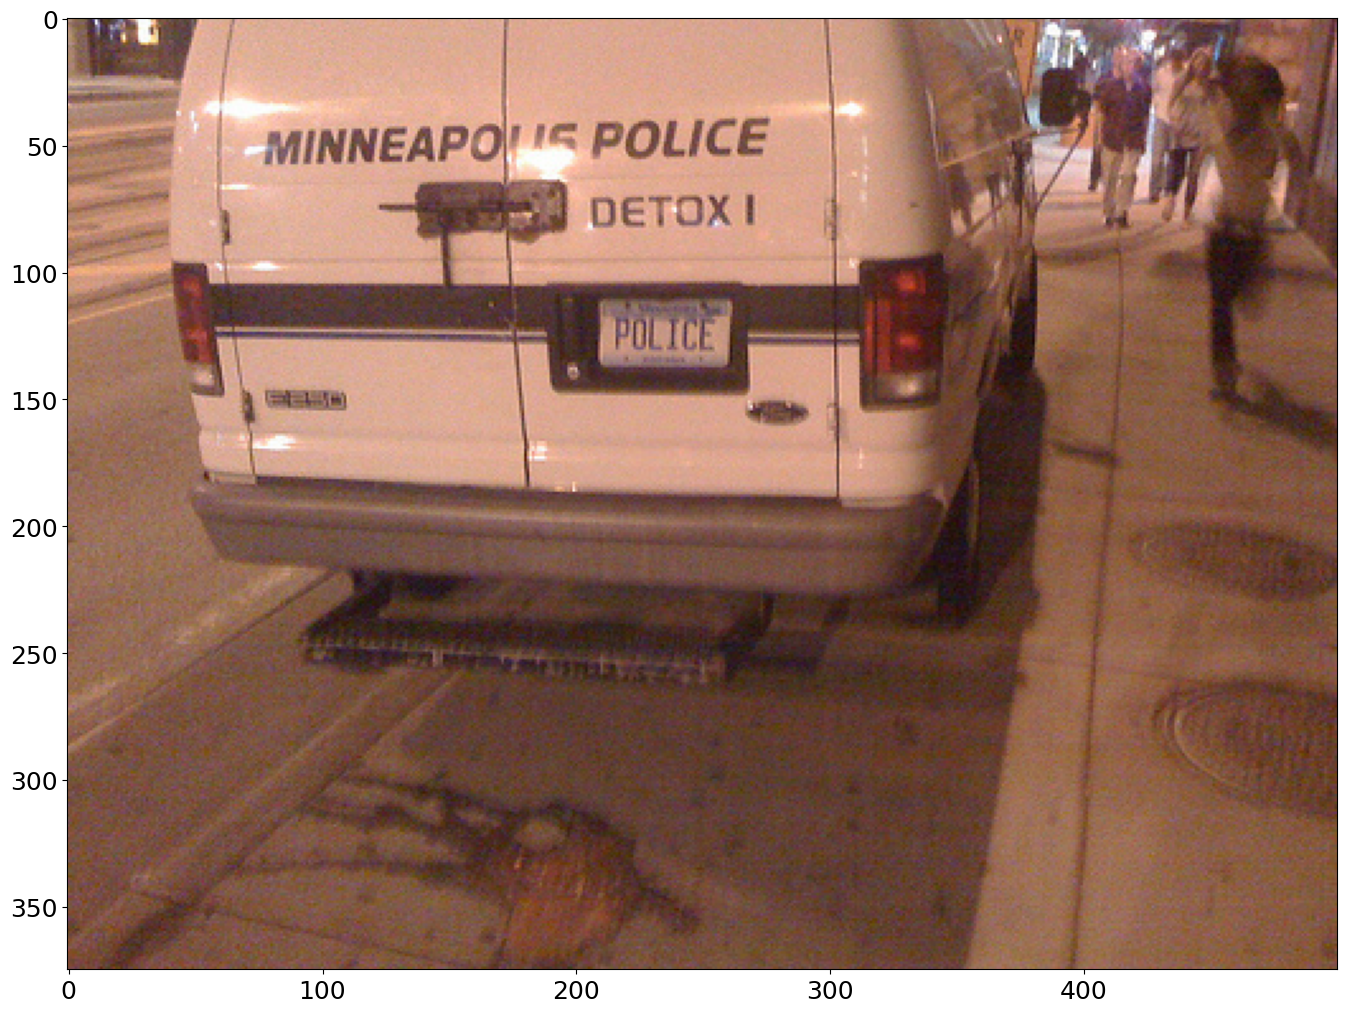

In [8]:
fig, ax = plt.subplots(figsize=(fig_width, fig_width/phi))
ax.imshow(torch.movedim(full_image.squeeze(0), (1, 2, 0), (0, 1, 2)).numpy())


## doing the computations

In [35]:
resolution = (128, 128)
resolution = (64, 64)
resolution = (32, 32)
size_ratio = 0.3 # how much of the image to use relative to radius
N_image = 100

In [51]:
for data_set_type in ['full']: # data_set_types:
    print(50*'=')
    print(f'{data_set_type=}')    

    args = Params()
    args.root  = f'{DATAROOT}/Imagenet_{data_set_type}' # Directory containing images
    args.folders = ['val'] # type of images to use
    print(50*'-')

    image_dataset = torchvision.datasets.ImageFolder(os.path.join(args.root, args.folders[0]), transform=T.Compose([T.ToImage(), T.ToDtype(torch.float32, scale=True)]))
    # dataloader = torch.utils.data.DataLoader(image_dataset, batch_size=1, shuffle=True, num_workers=1)
    idxs = np.random.permutation(len(image_dataset))[:N_image]

    for model_name in ['resnet101', 'resnet50', 'resnet18']:
        print(f'{model_name=}')    
        print(50*'.')

        for do_polar in [True, False]:
            args.do_polar = do_polar
            print(f'{args.do_polar=}')
            print(50*'.')
            df_filename = f'{data_cache}/{datetag}_{data_set_type}_{model_name}_{do_polar=}_results_likelihood-maps.parquet'
            if os.path.isfile(df_filename):
                df_map = pd.read_parquet(df_filename)
            else:
                model_filename = f'{data_cache}/{datetag}_{data_set_type}_{model_name}_{do_polar=}.pt'
                df_map = None
                if os.path.isfile(model_filename):
                    model = charge_model(model_name=model_name, model_path=model_filename, do_circular=args.do_polar).to(device).eval()

                    for i_image, idx in tqdm(enumerate(idxs)):
                        full_image, label = image_dataset[idx]
                        ImageId = os.path.basename(image_dataset.samples[idx][0].split('.')[0])

                        full_image = full_image.to(device)
                        full_image = full_image.squeeze(0)

                        N_fixations = np.prod(resolution)
                        aspect_ratio = full_image.shape[1]/full_image.shape[2]
                        resolution_ = (int(np.sqrt(N_fixations*aspect_ratio)),
                                       int(np.sqrt(N_fixations/aspect_ratio)))

                        pos_H, pos_W, box_size = get_positions(full_image, resolution, size_ratio)
                        args.image_size = box_size
                        args.do_polar = do_polar

                        pos_H, pos_W, outputs = compute_likelihood_map(args, model, full_image, resolution=resolution)
                        proba_label = outputs[:, label]

                        df_map_ = pd.DataFrame({'ImageId':ImageId, 'pos_H':pos_H.astype(int).ravel(), 'pos_W':pos_W.astype(int).ravel(), 'proba_label':proba_label})
                        if df_map is None:
                            df_map = df_map_
                        else:
                            df_map = pd.concat([df_map, df_map_], ignore_index=True)

                    df_map.to_parquet(df_filename)                        
                    print(25*'. ')
                else:
                    print(f' 😵‍💫 {model_filename} not found')
                    print(50*'-')
                    

data_set_type='full'
--------------------------------------------------
model_name='resnet101'
..................................................
args.do_polar=True
..................................................
loading .... cached_data/2024-04-25_full_resnet101_do_polar=True.pt


19it [06:50, 19.30s/it]

## reading localisation metadata

In [ ]:
with open(f'{args.root}/LOC_val_solution.csv', 'r') as csv_file:
    df_data = pd.read_csv(csv_file)

In [ ]:
df_data

,ImageId,PredictionString
0,ILSVRC2012_val_00048981,n03995372 85 1 499 272
1,ILSVRC2012_val_00037956,n03481172 131 0 499 254
2,ILSVRC2012_val_00026161,n02108000 38 0 464 280
3,ILSVRC2012_val_00026171,n03109150 0 14 216 299
4,ILSVRC2012_val_00008726,n02119789 255 142 454 329 n02119789 44 21 322 ...
...,...,...
49995,ILSVRC2012_val_00005961,n03388043 103 0 279 472
49996,ILSVRC2012_val_00008801,n03089624 101 286 170 374 n03089624 236 282 30...
49997,ILSVRC2012_val_00008176,n01518878 82 98 439 498
49998,ILSVRC2012_val_00004764,n03874293 91 111 490 420


In [ ]:
def get_boxes(df, value):
    idx = list(df['ImageId'][df['ImageId'] == value].index)
    bboxes = []
    if idx:
        for i in range(len(df["PredictionString"][idx[0]].split(' '))//5):
            pos =(5*i)
            bboxes.append({'xmin' : int(df["PredictionString"][idx[0]].split(' ')[1 + pos]),
                           'ymin' : int(df["PredictionString"][idx[0]].split(' ')[2 + pos]),
                           'xmax' : int(df["PredictionString"][idx[0]].split(' ')[3 + (5 *i)]),
                           'ymax' : int(df["PredictionString"][idx[0]].split(' ')[4 + (5 *i)])
                                        })
    return bboxes

In [ ]:
get_boxes(df_data, 'ILSVRC2012_val_00048981')

[{'xmin': 85, 'ymin': 1, 'xmax': 499, 'ymax': 272}]

## doing the figure

In [ ]:
for data_set_type in data_set_types:
    print(50*'=')
    print(f'{data_set_type=}')    
    for model_name in  ['resnet18', 'resnet50', 'resnet101']:
        print(f'{model_name=}')    
        print(50*'.')

        fig, axs = plt.subplots(len(image_names), 3, figsize=(fig_width*len(image_names), fig_width))
        for i_image, (image_name, true_label) in enumerate(zip(image_names, true_labels)):

            image_url = f'./imgs/{image_name}.jpg'
            full_image = read_image(image_url)/255
            full_image_np = torch.movedim(full_image, (1, 2, 0), (0, 1, 2)).numpy()
            three, H, W = full_image.shape

            ax = axs[i_image, 0]
            extent = (0, W, 0, H)
            ax.imshow(full_image_np, origin="upper", extent=extent)
            ax.set_xticks([])
            ax.set_yticks([])

            # ax.set_xticks([])
            pos_H, pos_W, box_size = get_positions(full_image, resolution, size_ratio)
            resolution = pos_H.shape
            for i_polar, do_polar in enumerate([False, True]):
                map_filename = f'{data_cache}/{datetag}_{data_set_type}_{model_name}_{do_polar=}_map_{image_name}.npy'
                if os.path.isfile(map_filename):
                    proba_label = np.load(map_filename)
                    proba_max = 1.
                    proba_max = proba_label.max()
                    mycmap = transparent_cmap(plt.cm.Reds if do_polar else plt.cm.Blues)
                    ax = axs[i_image,  i_polar+1]
                    ax.contourf(pos_W, H-pos_H, proba_label, levels=np.linspace(0, proba_max, 10), origin="upper", extent=extent, cmap=mycmap, vmin=0, vmax=proba_max, linewidths=3)
                    ax.set_xticks([])
                    ax.set_yticks([])
        # ax.scatter(500, 100, s=1000, c='r')
        # ax.set_yticks([])  
        fig.set_facecolor(color='white')
        plt.show()



In [ ]:
for ext in exts:
    fig.savefig(f'figs/fig-likelihood_map.{ext}',  **opts_savefig)